In [3]:
from utils.cnn_utils.data_preprocessor_utils import CNNPreprocessor

In [6]:
cnn_preprocessor = CNNPreprocessor(sensors_path="../../../../data/ml/features.csv", target_path="../../../../data/ml/targets.csv")

In [7]:
sensors_df, target_df = cnn_preprocessor.read_data()
sensors_df = cnn_preprocessor.feature_selection()
cnn_preprocessor.normalize_angle()
X = cnn_preprocessor.group_and_pad(cnn_preprocessor.sensor_df, group_col="Experiment_ID")
Y = cnn_preprocessor.group_and_pad(cnn_preprocessor.target_df, group_col="Experiment_ID")[:,:-1,1:-1]
X_rf, Y_rf = cnn_preprocessor.prepare_rf_data(X, Y)

In [ ]:
from utils.cnn_utils.model import MultiOutputCNN
from utils.cnn_utils.cnn_feature_importance import full_pipeline, get_experiment_analysis, plot_temporal_importance_with_real_names

In [9]:
# Initialize and train model
model = MultiOutputCNN(input_size=X.shape[-1], seq_len=X.shape[1], output_size=Y.shape[-1], num_angles=Y.shape[-2])

Training CNN Model...


Epoch 1/5:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5 | Train Loss: 0.0550 | Test Loss: 0.0323


Epoch 2/5 | Train Loss: 0.0437 | Test Loss: 0.0224


Epoch 3/5 | Train Loss: 0.0359 | Test Loss: 0.0160


Epoch 4/5 | Train Loss: 0.0300 | Test Loss: 0.0120


Epoch 5/5 | Train Loss: 0.0270 | Test Loss: 0.0096
Model saved to: ../../../../models/cnn/cnn.joblib


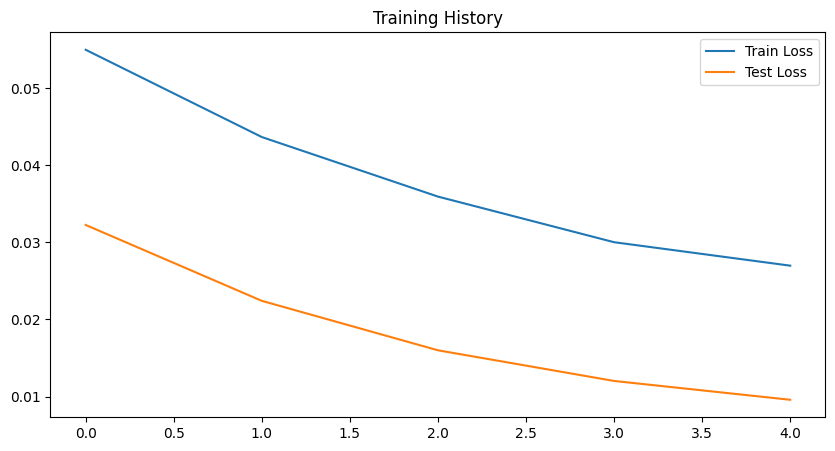

Visualizing Feature Importance...


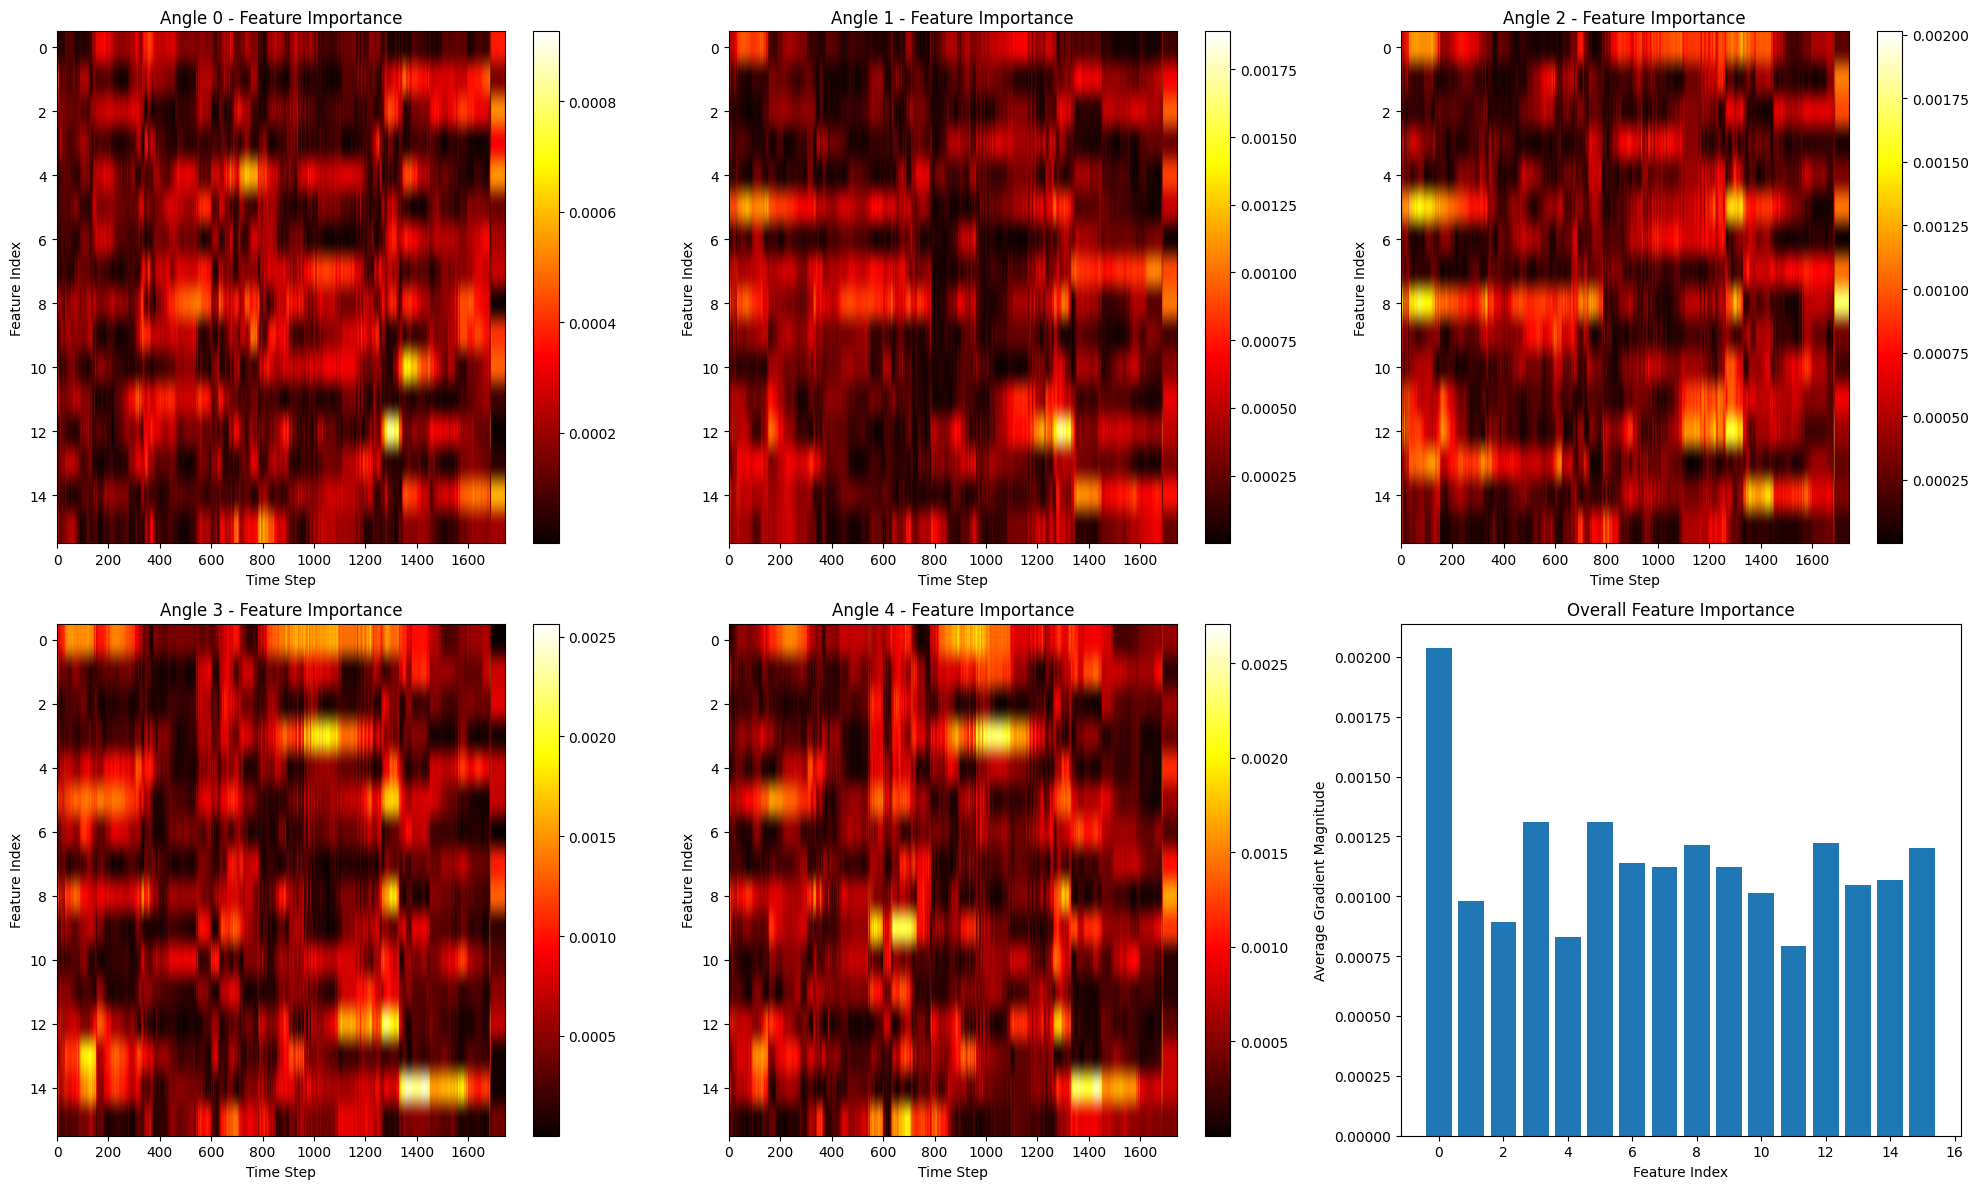

Computing Permutation Importance...


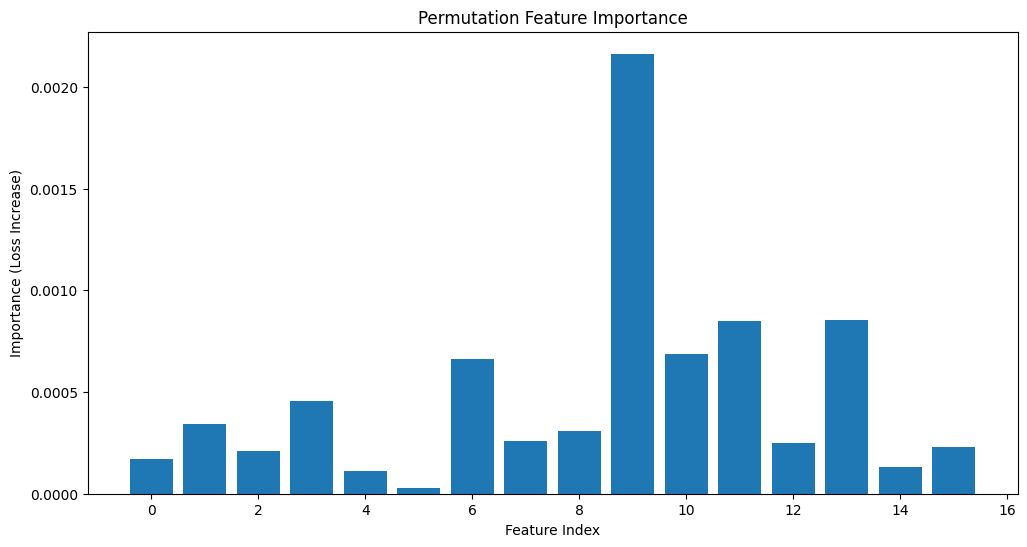

In [12]:
model, importance_maps, perm_importance = full_pipeline(X, Y, model, model_path="../../../../models/cnn/cnn.joblib", num_epochs=5, lr=0.0001)

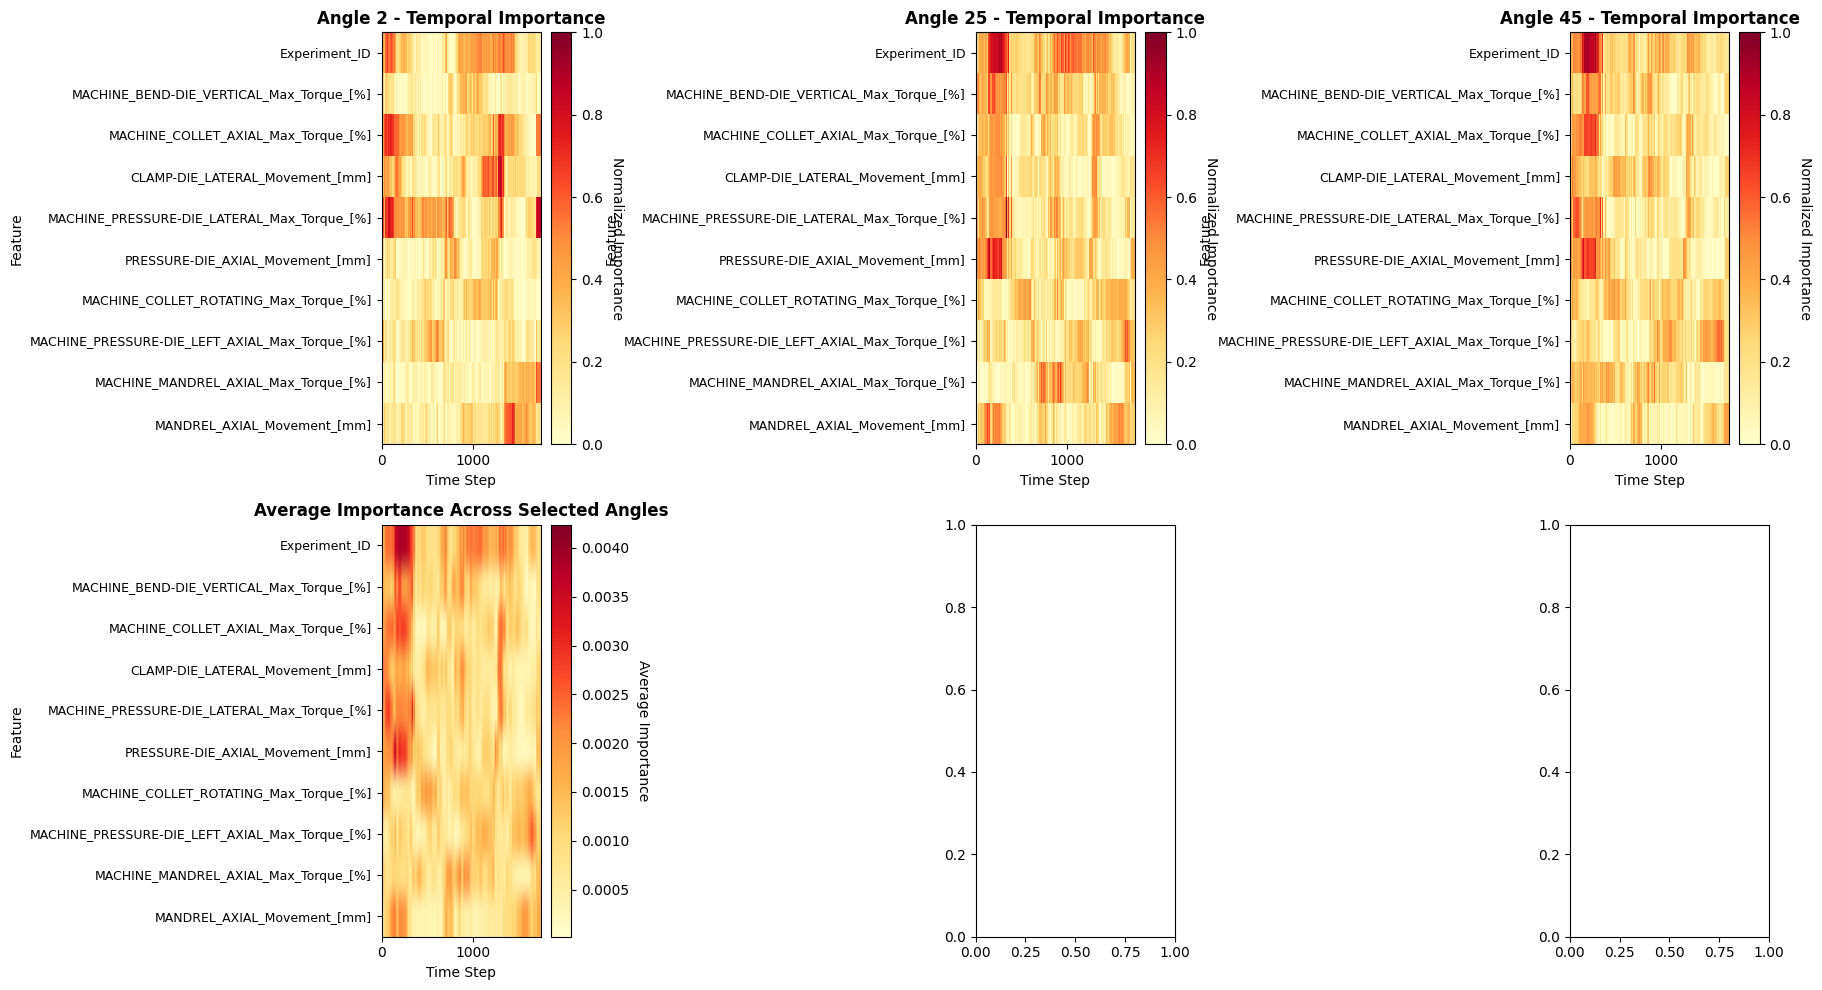

['Experiment_ID',
 'MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%]',
 'MACHINE_COLLET_AXIAL_Max_Torque_[%]',
 'CLAMP-DIE_LATERAL_Movement_[mm]',
 'MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%]',
 'PRESSURE-DIE_AXIAL_Movement_[mm]',
 'MACHINE_COLLET_ROTATING_Max_Torque_[%]',
 'MACHINE_PRESSURE-DIE_LEFT_AXIAL_Max_Torque_[%]',
 'MACHINE_MANDREL_AXIAL_Max_Torque_[%]',
 'MANDREL_AXIAL_Movement_[mm]']

In [13]:
plot_temporal_importance_with_real_names(importance_maps, sensors_df, selected_angles=[2, 25, 45])

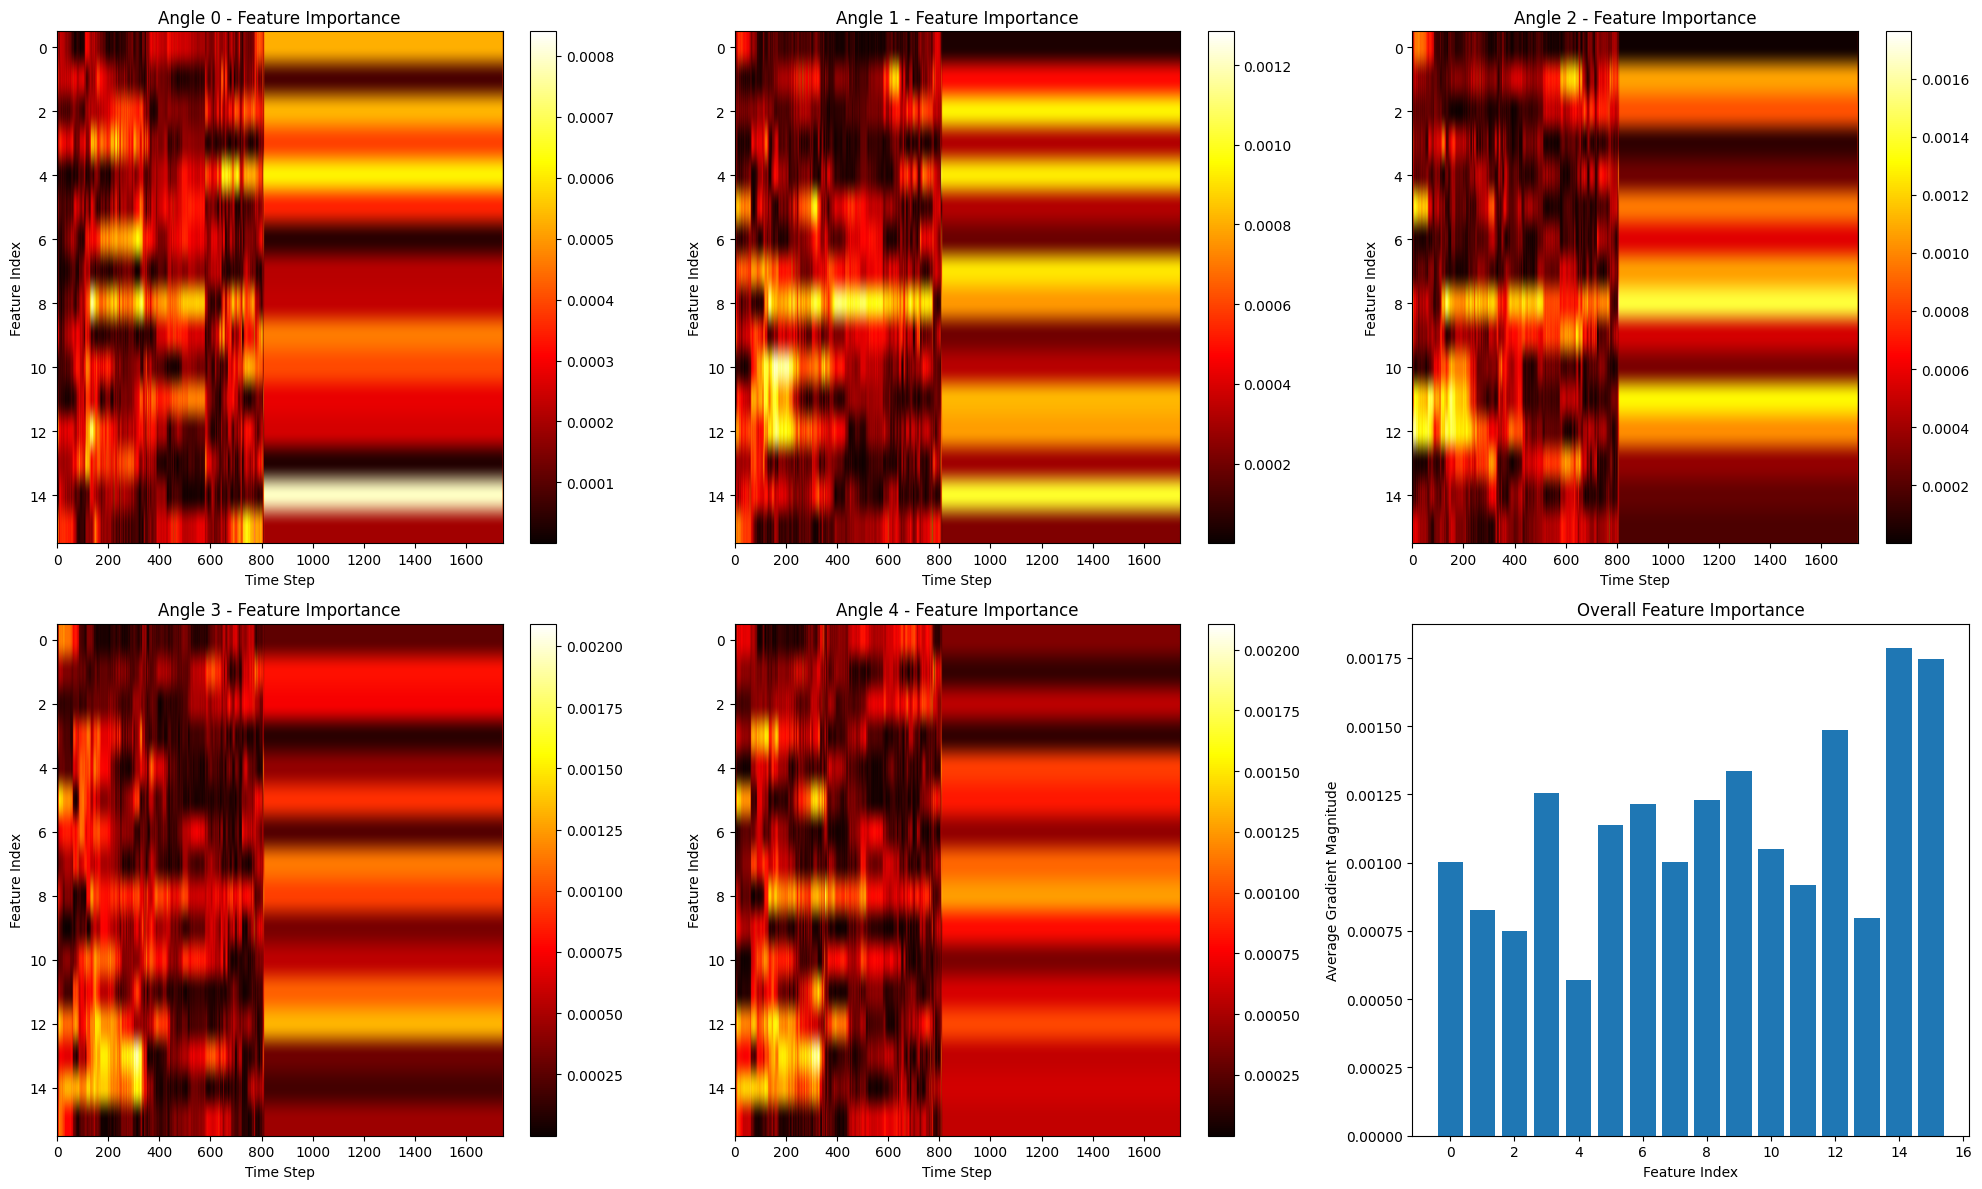

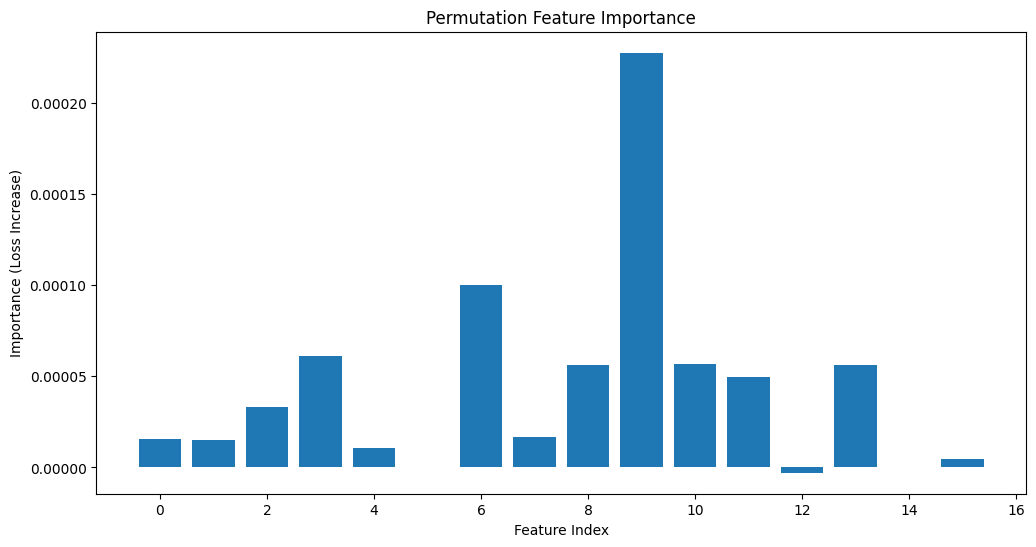

In [14]:
# After training your model
target_id = 2
experiment_ids=[2]
preds, temp_importance, perm_importance = get_experiment_analysis(
    model, X, Y, experiment_ids, target_experiment_id=target_id
)

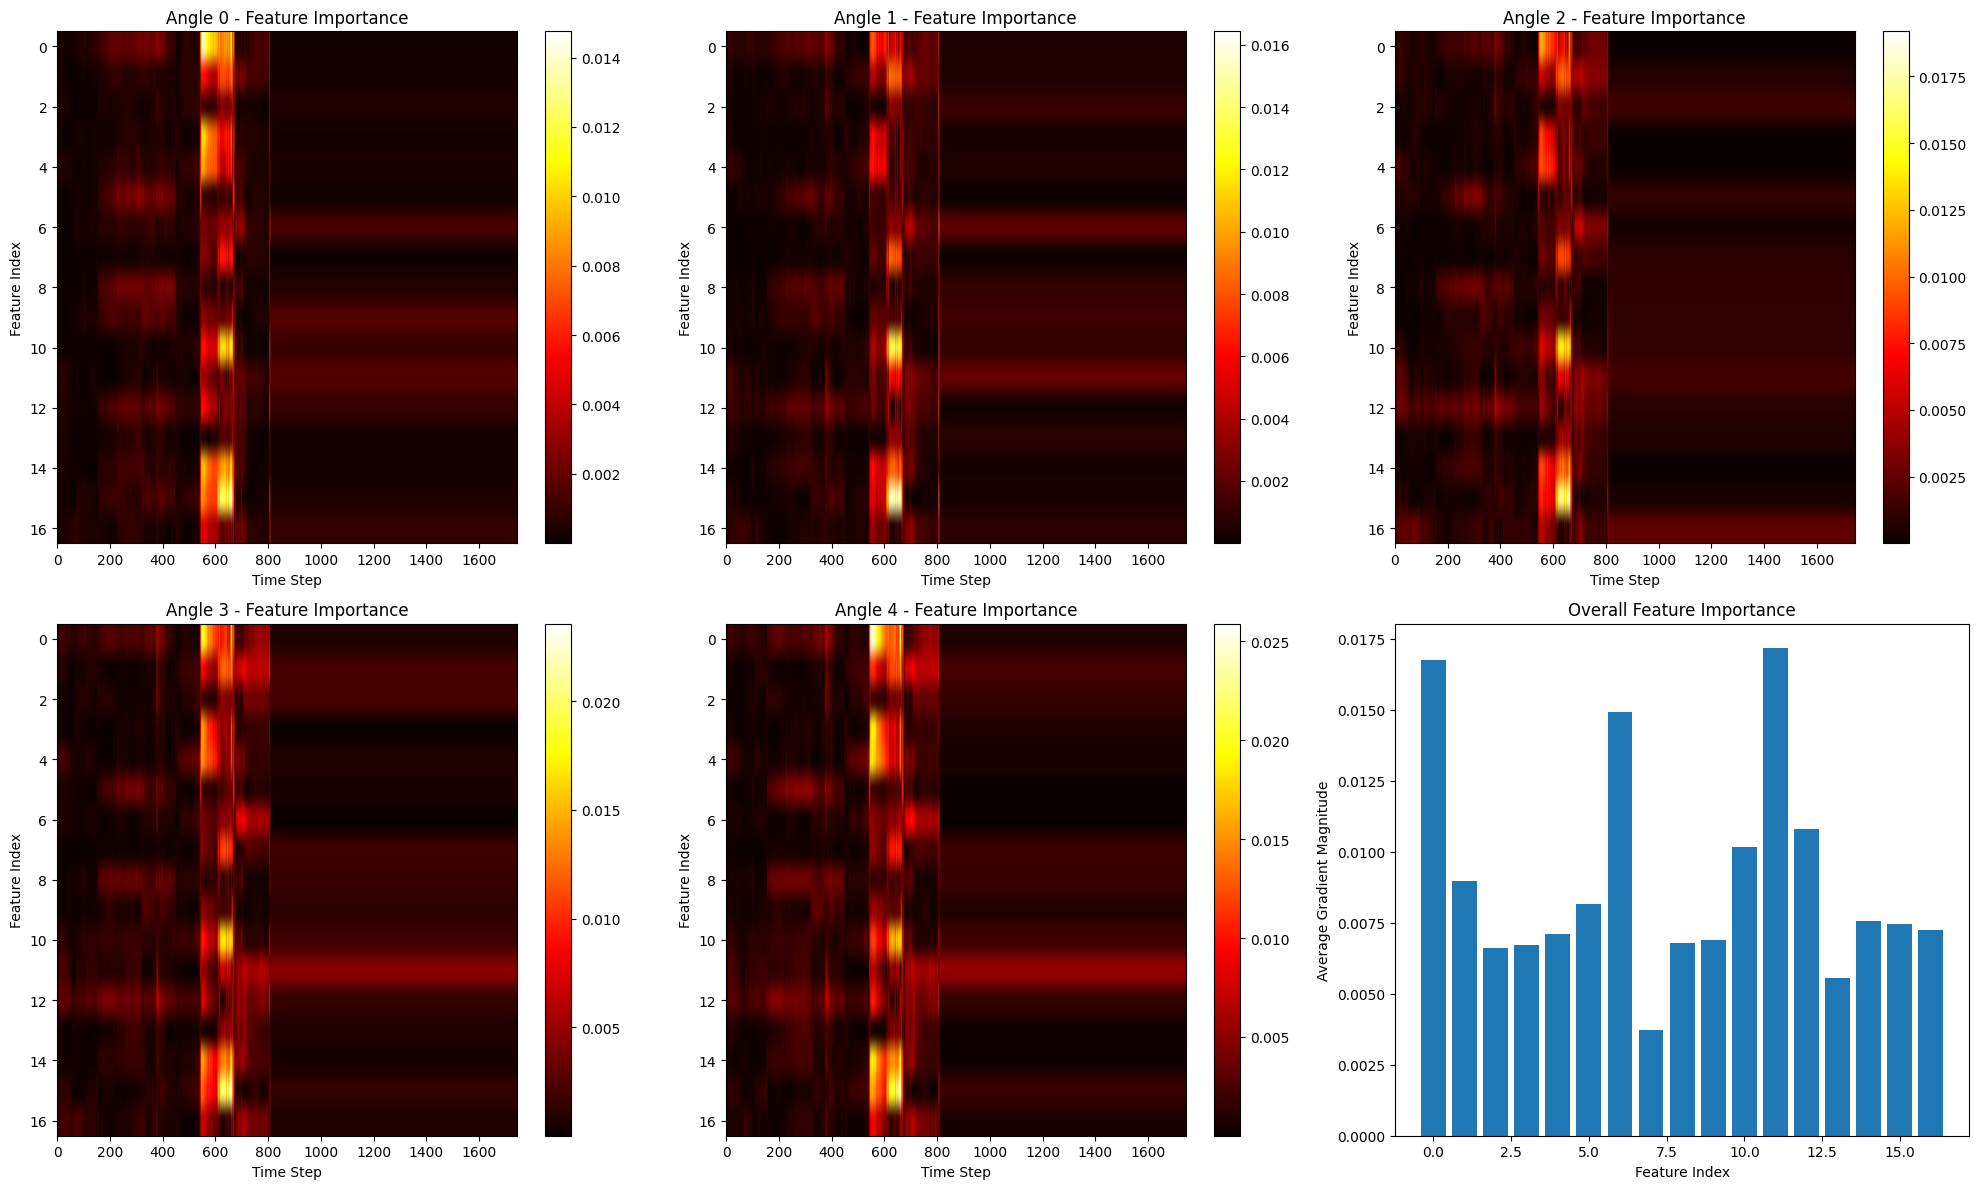

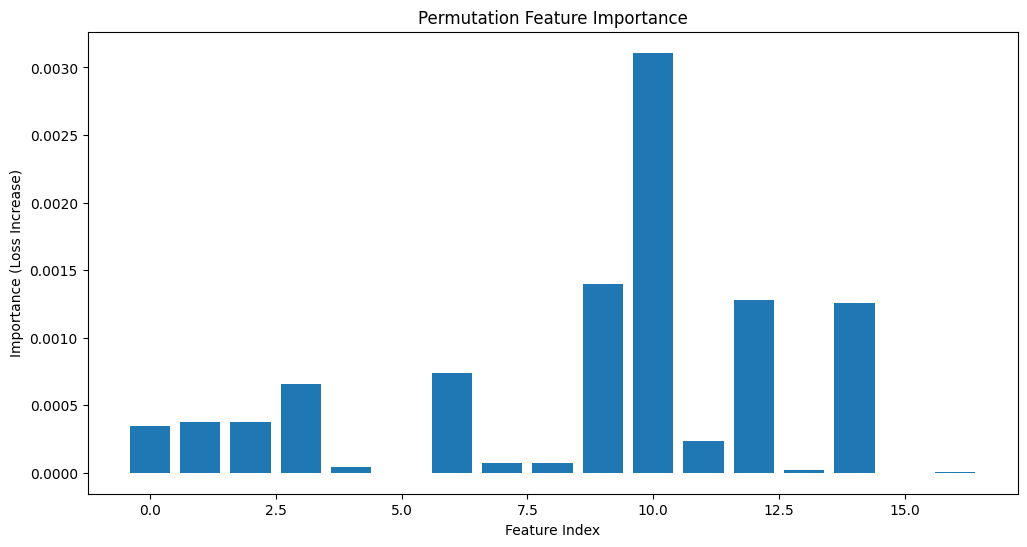

In [13]:
# After training your model
target_id = 4
experiment_ids=[4]
preds, temp_importance, perm_importance = get_experiment_analysis(
    model, X, Y, experiment_ids, target_experiment_id=target_id
)
